# Holiday Package Prediction

## 1.Problem Statement

Trip🧳and Travel🧭Company need viable business model to expand customer base.

"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering - Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.



## 2.Data Collection

The dataset is taken from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction .

## 3.Importing required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## 4.Reading data

In [ ]:
df=pd.read_csv(f'Travel.csv')
df.head()

## 5.Data Cleaning

### Handling Missing values

In [ ]:
df.shape

In [ ]:
df.isnull().sum()

In [ ]:
df.info()

In [ ]:
categorical_columns=['ProdTaken','TypeofContact','CityTier','Occupation','Gender','ProductPitched','MaritalStatus','Passport','OwnCar','Designation']

for column in categorical_columns:
    print(column)
    print(df[column].value_counts())
    print()

In [ ]:
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [ ]:
print(df['Gender'].value_counts())
print()
print(df['MaritalStatus'].value_counts())

In [ ]:
# Checking Missing Values

features_with_na=[feature for feature in df.columns if df[feature].isnull().sum()>=1]

print("% of Missing Values:\n")
for feature in features_with_na:
    print(feature,':',np.round(df[feature].isnull().mean()*100,3),'%')
    

### Summary Statistics on Numerical Columns(Null Cols)

In [ ]:
df[features_with_na].describe(exclude='object')

### Imputing Null Values

In [ ]:
df['Age'].fillna(df['Age'].median(),inplace=True)
df['TypeofContact'].fillna(df['TypeofContact'].mode()[0],inplace=True)
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(),inplace=True)
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0],inplace=True)
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0],inplace=True)
df['NumberOfTrips'].fillna(0,inplace=True)
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0],inplace=True)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(),inplace=True)

In [ ]:
df.isnull().sum()

### Summary Statistics on Categorical Columns

In [ ]:
df.describe(include='object').T

In [ ]:
df.drop(['CustomerID'],axis=1,inplace=True)

## Feature Engineering

In [ ]:
df.head()

### Feature Extraction

In [ ]:
df['TotalVisiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], axis=1, inplace=True)

In [ ]:
# Get all the numeric,categorical,discrete and continuous features

num_features=[feature for feature in df.columns if df[feature].dtype != 'O']
cat_features=[feature for feature in df.columns if df[feature].dtype == 'O']
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
continuous_features=[feature for feature in num_features if feature not in discrete_features]

print('No.of Numerical Features:',len(num_features))
print('No.of Categorical Features:',len(cat_features))
print('No.of Discrete Features:',len(discrete_features))
print('No.of Continuous Features:',len(continuous_features))

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
X_train

In [ ]:
X.head()

In [ ]:
X.info()

In [ ]:
y.value_counts()

### Applying Column Transformer

1.OneHotEncoder
2.StandardScaler

In [ ]:
cat_features=X.select_dtypes(include='object').columns
num_features=X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features)
    ]

)

In [ ]:
preprocessor

In [ ]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

## Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

In [ ]:
models={'Logistic Regression':LogisticRegression(),
        'Decision Tree':DecisionTreeClassifier(),
        'Random Forest':RandomForestClassifier(),
        'Gradient Boost':GradientBoostingClassifier()
       }

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    
    # Preditcions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    
    # Training data performance
    model_train_accuracy=accuracy_score(y_train,y_train_pred)
    model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
    model_train_prediction=precision_score(y_train,y_train_pred)
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)
    
    # Testing data performance
    model_test_accuracy=accuracy_score(y_test,y_test_pred)
    model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
    model_test_prediction=precision_score(y_test,y_test_pred)
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model Performance for Training data')
    print('-Accuracy: {:.4f}'.format(model_train_accuracy))
    print('-F1 score: {:.4f}'.format(model_train_f1))
    print('-Recall: {:.4f}'.format(model_train_recall))
    print('-ROC AUC score:{:.4f}'.format(model_train_rocauc_score))
    
    print('-'*40)
    
    
    print('Model Performance for Testing data')
    print('-Accuracy: {:.4f}'.format(model_test_accuracy))
    print('-F1 score: {:.4f}'.format(model_test_f1))
    print('-Recall: {:.4f}'.format(model_test_recall))
    print('-ROC AUC score:{:.4f}'.format(model_test_rocauc_score))
    
    print('='*40)
    print('\n')


### Hyperparameter Tuning

In [ ]:
rf_params={
    'max_depth':[5,8,15,None,10],
    'max_features':[5,7,'auto',8],
    'min_samples_split':[2,8,14,20],
    'n_estimators':[100,200,500,1000]
}


random_cv_models=[('RF',RandomForestClassifier(),rf_params)]
random_cv_models

In [42]:
from sklearn.model_selection import RandomizedSearchCV

model_param={}
for name,model,params in random_cv_models:
    random=RandomizedSearchCV(estimator=model,n_iter=100,param_distributions=params,cv=3,verbose=2,n_jobs=-1)
    random.fit(X_train,y_train)
    model_param[name]=random.best_params_

for model_name in model_param:
    print('\n')
    print(f'----------Best Params for---------- {model_name}')
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits


----------Best Params for---------- RF
{'n_estimators': 200, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}


### Training data on Random Forest Model(The Best Model)

In [43]:
rf_clf=RandomForestClassifier(n_estimators=200,min_samples_split=2,max_features=8,max_depth=None)

In [45]:
model=rf_clf

model.fit(X_train,y_train)

# Preditcions
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)

# Training data performance
model_train_accuracy=accuracy_score(y_train,y_train_pred)
model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
model_train_prediction=precision_score(y_train,y_train_pred)
model_train_recall=recall_score(y_train,y_train_pred)
model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)

# Testing data performance
model_test_accuracy=accuracy_score(y_test,y_test_pred)
model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
model_test_prediction=precision_score(y_test,y_test_pred)
model_test_recall=recall_score(y_test,y_test_pred)
model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)

print('Model Performance for Training data')
print('-Accuracy: {:.4f}'.format(model_train_accuracy))
print('-F1 score: {:.4f}'.format(model_train_f1))
print('-Recall: {:.4f}'.format(model_train_recall))
print('-ROC AUC score:{:.4f}'.format(model_train_rocauc_score))

print('-'*40)


print('Model Performance for Testing data')
print('-Accuracy: {:.4f}'.format(model_test_accuracy))
print('-F1 score: {:.4f}'.format(model_test_f1))
print('-Recall: {:.4f}'.format(model_test_recall))
print('-ROC AUC score:{:.4f}'.format(model_test_rocauc_score))

print('='*40)
print('\n')


Model Performance for Training data
-Accuracy: 1.0000
-F1 score: 1.0000
-Recall: 1.0000
-ROC AUC score:1.0000
----------------------------------------
Model Performance for Testing data
-Accuracy: 0.9264
-F1 score: 0.9211
-Recall: 0.6533
-ROC AUC score:0.8212




### Plotting Reciever Operating Characteristic Curve (ROC Curve)

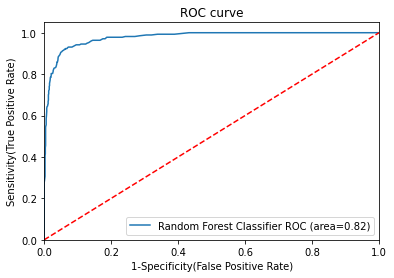

In [57]:
from sklearn.metrics import roc_curve
plt.figure()

fpr,tpr,thresholds=roc_curve(y_test,model.predict_proba(X_test)[:,-1])
plt.plot(fpr,tpr,label='%s ROC (area=%0.2f)' % ('Random Forest Classifier',0.8212))
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('ROC curve')
plt.legend(loc='lower right')
plt.show();